In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [3]:
header = "D:/K_sunada/database/"
pl = "/2023-06-21/2023-06-21T131722_85016f26-td_ge_T2r1d"
mi = "/2023-06-21/2023-06-21T131915_c885bf01-td_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

+5MHz

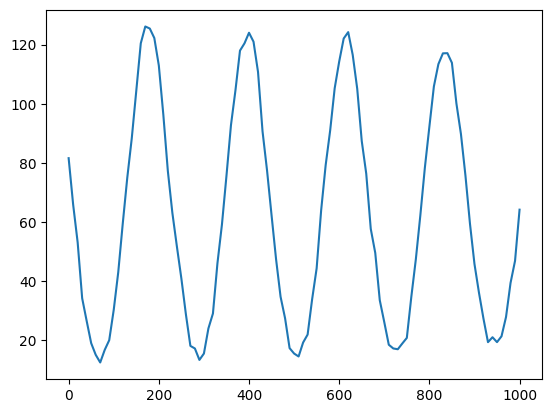

In [4]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

plt.plot(delay_pl, imag_pl)
plt.show()

In [5]:
par_ini = {
    'amp': 60,
    'phi0':-np.pi/2,
    'detun':1/220,
    'const':70
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [6]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [7]:
result_pl = model.fit(data = imag_pl, params = params, delay = delay_pl)

In [8]:
result_pl

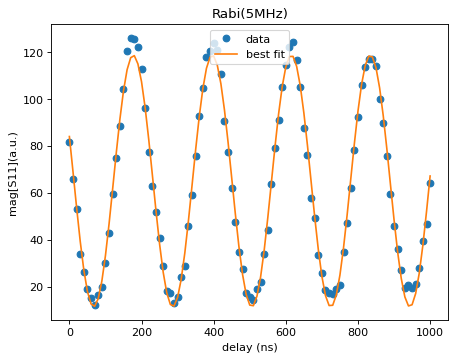

In [9]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
#plt.plot(delay_pl,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

-5MHz

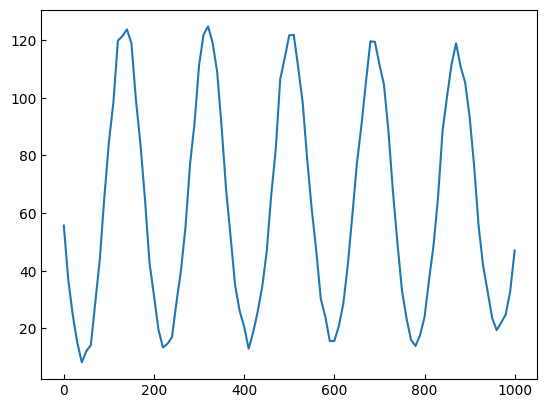

In [10]:
Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

plt.plot(delay_mi, imag_mi)
plt.show()

In [11]:
par_ini = {
    'amp': 60,
    'phi0':-np.pi/2,
    'detun':1/200,
    'const':70
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [12]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [13]:
result_mi = model.fit(data = imag_mi, params = params, delay = delay_mi)

In [14]:
result_mi

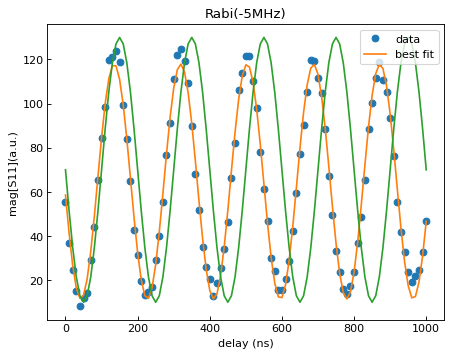

In [15]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(delay_mi,result_mi.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

In [16]:
detun = ((0.005-0.00456366)+ (0.00542674-0.005))/2 #GHz
detun

0.0004315400000000002

ge　較正後 Rabi

In [17]:
ge = "/2023-06-21/2023-06-21T180459_b3218e12-td_ge_pi_amp"
dd_ge = datadict_from_hdf5(header + ge +"/data")

In [18]:
import sklearn
from sklearn.decomposition import PCA

In [19]:
Rabi_ge = dd_ge['s11']['values']
#imag_ge = Rabi_ge.imag
amp_ge = dd_ge['amplitude']['values']

I = (Rabi_ge.real)
Q = (Rabi_ge.imag)

In [20]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [21]:
PCAge = PCA_transform(I, Q)

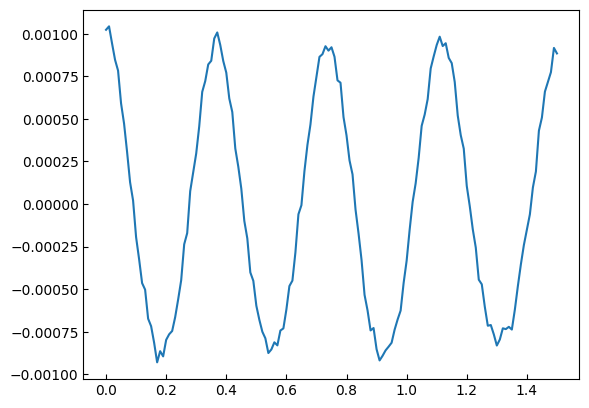

In [22]:
y = PCAge[0]
x = amp_ge

plt.plot(x, y)
plt.show()

In [23]:
par_ini = {
    'amp': 0.001,
    'phi0':np.pi,
    'detun':1/0.4,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [24]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [25]:
result_ge = model.fit(data = y, params = params, delay = x)
result_ge

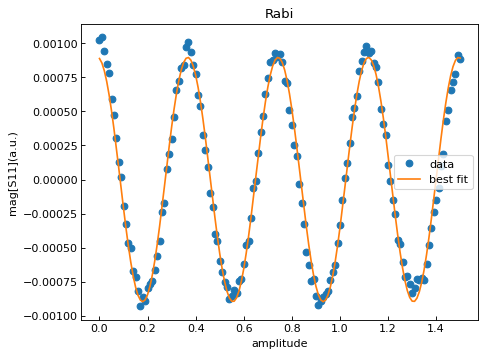

In [26]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_ge.plot_fit(ax = ax)
#plt.plot(amp_ge,result_ge.init_fit)

plt.xlabel("amplitude")
plt.ylabel("mag[S11](a.u.)")


plt.show()
ge = "/2023-06-21/2023-06-21T164546_a1ccda23-td_ge_T2r1d"
dd_ge = datadict_from_hdf5(header + ge +"/data")

In [27]:
# def Rabi(delay, amp, phi0, detun, const):
#     return - amp * np.cos(2*np.pi*detun*delay+phi0) + con

np.pi/(2.66391709*2*np.pi)

0.18769352915559395